In [1]:
from google.colab import files
uploaded = files.upload()

Saving typosquat_dataset_full.zip to typosquat_dataset_full.zip


In [2]:
import zipfile, os

with zipfile.ZipFile('typosquat_dataset_full.zip', 'r') as zf:
    zf.extractall('dataset/')

# Check files
for root, dirs, files in os.walk('dataset/'):
    for f in files:
        print(os.path.join(root, f))

dataset/typosquat_dataset_full/typosquat_tool_calls.jsonl


In [ ]:
import json

with open('dataset/typosquat_dataset_full/typosquat_tool_calls.jsonl', 'r') as f:
    line = f.readline()
    print(json.dumps(json.loads(line), indent=2))

{
  "id": "b4a06ba5-bed7-4cf3-ada2-651e42f6954f",
  "clean_command": "python -m pip install jpype1",
  "typo_command": "python -m pip install jpyyyye1",
  "mutation_type": "mixed",
  "edit_distance": 3,
  "package_name": "jpype1",
  "typo_package": "jpyyyye1",
  "exists_on_registry": false,
  "is_adversarial": true,
  "tool": "pip",
  "split": "train"
}


Not running in Colab or Drive not mounted; results will be saved locally.
Loading dataset...
Train: 2249, Test: 483


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Extracting hidden states for train set...
Extracting hidden states for test set...
X_train: (2249, 1536), X_test: (483, 1536)
Training baseline probe (Logistic Regression)...
Probe AUC: train 1.0000, test 0.9820
Building 30 orthogonal probe directions (multi‑direction depletion)...


Orthogonalization:   3%|▎         | 1/30 [00:06<02:59,  6.21s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Orthogonalization:   7%|▋         | 2/30 [00:16<03:56,  8.45s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation

W shape: (30, 1536)
Orthonormality check: dot(W[0], W[1]) = 2.26e-17 (should be ~0)
Running 1000 Monte Carlo permutations for Shapley...


Permutations: 100%|██████████| 1000/1000 [02:52<00:00,  5.78it/s]


Full set AUC: 0.9820
Sum Shapley: 0.4820 (expected 0.4820)


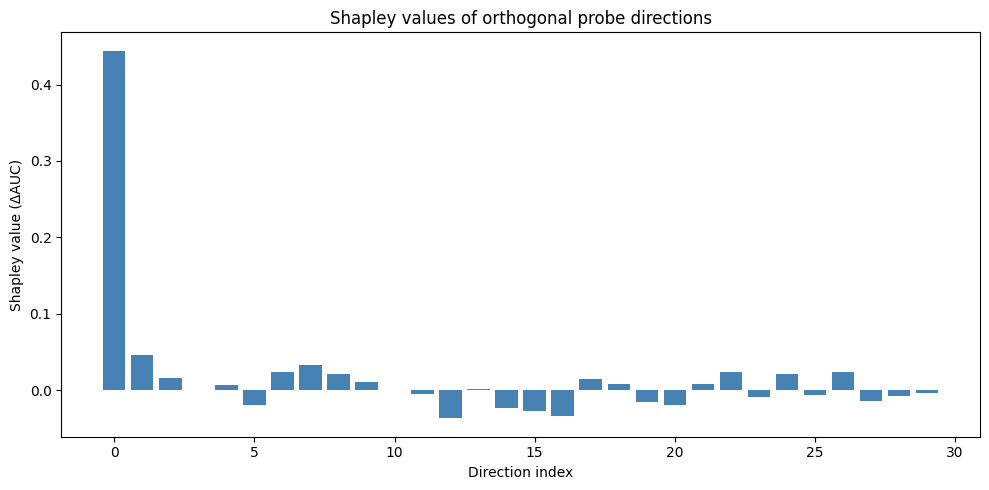

Top‑5 directions (by Shapley): [0, 1, 7, 6, 26]
Shapley values: [0.4442 0.0461 0.0329 0.0242 0.0239]

✅ Pipeline complete.


In [ ]:
# =============================================================================
#  FULL PIPELINE: Shapley credit assignment for multi‑direction depletion
#  (typosquatting / Qwen‑2.5‑1.5B)
# =============================================================================

# ----------------------------- IMPORTS -----------------------------
import json, os, pickle, time, zipfile
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, AutoModelForCausalLM

# ----------------------------- CONFIG -----------------------------
# Layer used for probing (keep consistent with your previous work)
PROBE_LAYER = 26
BATCH_SIZE = 16          # reduce if you get OOM
N_DIRECTIONS = 30        # number of orthogonal directions to build
N_PERMUTATIONS = 1000    # Monte Carlo permutations for Shapley
SUBSAMPLE_TEST = 2000    # set to None to use all test samples (slower)
BASELINE_AUC = 0.5       # chance AUC for a balanced binary task

# ---- Google Drive mount (optional) ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_PATH = '/content/drive/MyDrive/typosquat_shapley'
    os.makedirs(DRIVE_PATH, exist_ok=True)
    print(f"Results will be saved to {DRIVE_PATH}")
except:
    DRIVE_PATH = None
    print("Not running in Colab or Drive not mounted; results will be saved locally.")

# --------------------- 1. LOAD RAW DATA ---------------------
# Extract the zip if not already done
if not os.path.exists('dataset/typosquat_dataset_full'):
    with zipfile.ZipFile('typosquat_dataset_full.zip', 'r') as zf:
        zf.extractall('dataset/')

DATA_PATH = 'dataset/typosquat_dataset_full/typosquat_tool_calls.jsonl'
print("Loading dataset...")
texts, labels, splits = [], [], []
with open(DATA_PATH, 'r') as f:
    for line in f:
        obj = json.loads(line)
        if obj['is_adversarial']:
            texts.append(obj['typo_command'])
            labels.append(1)
        else:
            texts.append(obj['clean_command'])
            labels.append(0)
        splits.append(obj['split'])

texts = np.array(texts)
labels = np.array(labels)
splits = np.array(splits)

train_idx = splits == 'train'
test_idx = splits == 'test'
train_texts, y_train = texts[train_idx], labels[train_idx]
test_texts, y_test = texts[test_idx], labels[test_idx]

print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

# --------------------- 2. LOAD MODEL & EXTRACT HIDDEN STATES ---------------------
model_name = "Qwen/Qwen2.5-1.5B"

# Load tokenizer & model (use bfloat16 if GPU is Ampere+)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.float16,   # or torch.bfloat16
    device_map="auto"
)
model.eval()

def get_hidden_states(text_list, layer_idx=PROBE_LAYER, batch_size=BATCH_SIZE):
    """Return [n, hidden_dim] from specified hidden layer (mean pooling)."""
    all_hidden = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden = outputs.hidden_states[layer_idx]   # [bs, seq_len, dim]
        # mean pool over sequence length
        mean_hidden = hidden.mean(dim=1).cpu().float().numpy()
        all_hidden.append(mean_hidden)
    return np.concatenate(all_hidden, axis=0)

print("Extracting hidden states for train set...")
X_train = get_hidden_states(train_texts)
print("Extracting hidden states for test set...")
X_test = get_hidden_states(test_texts)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Optional: save extracted states to avoid recomputation
if DRIVE_PATH:
    np.save(os.path.join(DRIVE_PATH, 'X_train.npy'), X_train)
    np.save(os.path.join(DRIVE_PATH, 'X_test.npy'), X_test)
    np.save(os.path.join(DRIVE_PATH, 'y_train.npy'), y_train)
    np.save(os.path.join(DRIVE_PATH, 'y_test.npy'), y_test)

# --------------------- 3. TRAIN THE BASELINE PROBE ---------------------
print("Training baseline probe (Logistic Regression)...")
probe = LogisticRegression(max_iter=1000).fit(X_train, y_train)
train_auc = roc_auc_score(y_train, probe.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, probe.predict_proba(X_test)[:,1])
print(f"Probe AUC: train {train_auc:.4f}, test {test_auc:.4f}")

# Save probe
if DRIVE_PATH:
    with open(os.path.join(DRIVE_PATH, 'probe.pkl'), 'wb') as f:
        pickle.dump(probe, f)

# --------------------- 4. BUILD ORTHOGONAL DIRECTIONS W ---------------------
print(f"Building {N_DIRECTIONS} orthogonal probe directions (multi‑direction depletion)...")
d = X_train.shape[1]
remaining = X_train.copy()
ortho_directions = []
auc_history = []

for i in tqdm(range(N_DIRECTIONS), desc='Orthogonalization'):
    # Train probe on current subspace
    p = LogisticRegression(max_iter=1000).fit(remaining, y_train)
    w = p.coef_[0]             # (d,)
    w = w / np.linalg.norm(w)

    # Gram‑Schmidt orthogonalization against previous directions
    for prev in ortho_directions:
        w -= np.dot(w, prev) * prev
    w = w / np.linalg.norm(w)
    ortho_directions.append(w)

    # Deplete the component along w from the training data
    proj = remaining @ w       # (n,)
    remaining -= np.outer(proj, w)

    # Evaluate the probe's performance on the depleted test set (optional)
    # Not necessary for building W, but good sanity check.
    test_proj = X_test @ w     # project test data onto w
    # For a quick AUC drop, you could use a simple linear score, but here we skip
    auc_history.append(np.nan)  # placeholder; you can compute later

W = np.stack(ortho_directions)  # (n_directions, d)
print(f"W shape: {W.shape}")

# Save W
if DRIVE_PATH:
    np.save(os.path.join(DRIVE_PATH, 'W.npy'), W)

# Quick orthonormality check
dot0 = np.dot(W[0], W[1])
print(f"Orthonormality check: dot(W[0], W[1]) = {dot0:.2e} (should be ~0)")

# --------------------- 5. SHAPLEY ANALYSIS ---------------------
# Subsample test set for speed
if SUBSAMPLE_TEST is not None and len(X_test) > SUBSAMPLE_TEST:
    idx = np.random.choice(len(X_test), SUBSAMPLE_TEST, replace=False)
    X_sub = X_test[idx]
    y_sub = y_test[idx]
else:
    X_sub = X_test
    y_sub = y_test

value_cache = {}
def coalition_value(subset_indices):
    """AUC when projecting onto the span of the chosen directions."""
    key = frozenset(subset_indices)
    if key in value_cache:
        return value_cache[key]
    if not subset_indices:
        val = BASELINE_AUC
    else:
        selected_W = W[list(subset_indices)]
        coeffs = X_sub @ selected_W.T
        X_proj = coeffs @ selected_W
        val = roc_auc_score(y_sub, probe.predict_proba(X_proj)[:, 1])
    value_cache[key] = val
    return val

print(f"Running {N_PERMUTATIONS} Monte Carlo permutations for Shapley...")
marginal_contributions = defaultdict(list)
for _ in tqdm(range(N_PERMUTATIONS), desc='Permutations'):
    perm = np.random.permutation(N_DIRECTIONS)
    S = set()
    prev_val = coalition_value(S)
    for i in perm:
        S.add(i)
        curr_val = coalition_value(S)
        marginal_contributions[i].append(curr_val - prev_val)
        prev_val = curr_val

shapley = np.array([np.mean(marginal_contributions[i]) for i in range(N_DIRECTIONS)])

# Sanity check: sum(Shapley) should equal full_set_auc - baseline
full_auc = coalition_value(set(range(N_DIRECTIONS)))
print(f"Full set AUC: {full_auc:.4f}")
print(f"Sum Shapley: {shapley.sum():.4f} (expected {full_auc - BASELINE_AUC:.4f})")

# --------------------- 6. PLOTTING & REPORTING ---------------------
plt.figure(figsize=(10,5))
plt.bar(range(N_DIRECTIONS), shapley, color='steelblue')
plt.xlabel("Direction index")
plt.ylabel("Shapley value (ΔAUC)")
plt.title("Shapley values of orthogonal probe directions")
plt.tight_layout()
plt.show()

# Top‑5 directions
top5 = np.argsort(shapley)[-5:][::-1]
print("Top‑5 directions (by Shapley):", top5.tolist())
print("Shapley values:", shapley[top5].round(4))

# Save Shapley values
if DRIVE_PATH:
    np.save(os.path.join(DRIVE_PATH, 'shapley.npy'), shapley)
    print(f"Saved shapley.npy to {DRIVE_PATH}")

print("\n✅ Pipeline complete.")

Baseline accuracy (full set): 0.9648
Banzhaf Power Index (avg swing probability):
  Dir 0: 0.464348
  Dir 29: 0.000000
  Dir 27: 0.000000
  Dir 26: 0.000000
  Dir 25: 0.000000
  Dir 28: 0.000000
  Dir 23: 0.000000
  Dir 22: 0.000000
  Dir 21: 0.000000
  Dir 20: 0.000000


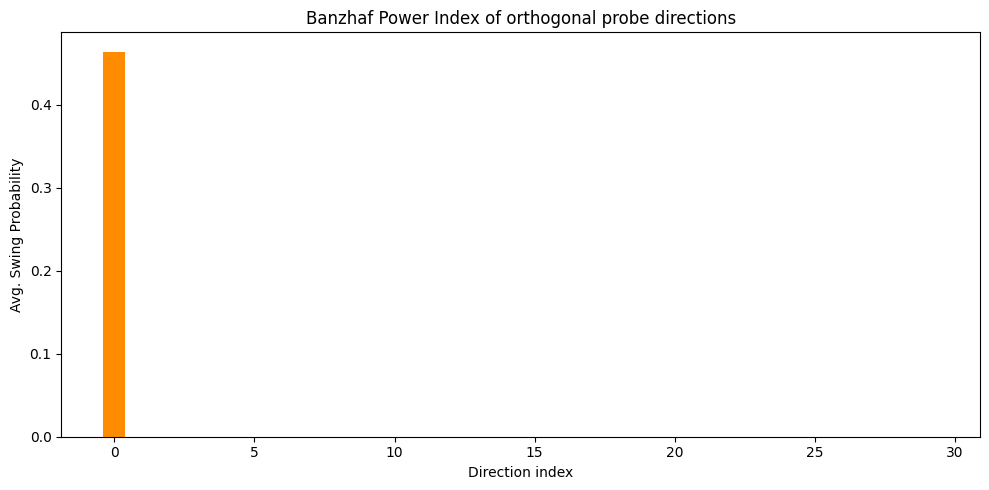

In [ ]:
# --- Banzhaf Power Index ---
# Requires: X_sub, y_sub, probe, W, BASELINE_AUC
from sklearn.metrics import accuracy_score
import numpy as np

def coalition_prediction(subset_indices):
    """Return probability scores for the positive class (for binary decision)."""
    if not subset_indices:
        X_proj = np.zeros_like(X_sub)
    else:
        selected_W = W[list(subset_indices)]
        coeffs = X_sub @ selected_W.T
        X_proj = coeffs @ selected_W
    return probe.predict_proba(X_proj)[:, 1]  # shape (n_samples,)

# Threshold for decision: 0.5 is natural, but you could use the probe's optimal threshold
threshold = 0.5
# True labels
y_true = y_sub

# Baseline accuracy using full set of directions
full_pred = coalition_prediction(set(range(len(W)))) > threshold
baseline_acc = accuracy_score(y_true, full_pred)
print(f"Baseline accuracy (full set): {baseline_acc:.4f}")

# Sampling random coalitions for Banzhaf
n_samples = len(y_sub)
num_coalitions = 1000  # number of random coalitions per direction
banzhaf = np.zeros(len(W))  # total swing count

for _ in range(num_coalitions):
    # Random coalition without direction i
    # We'll pick a random subset, then for each direction, see if adding it changes a decision
    # Efficient: for each sample, record which directions are "critical" in this coalition
    # Approach: generate random coalition size k from uniform(0, n_dirs-1)
    k = np.random.randint(0, len(W))
    coalition = set(np.random.choice(len(W), size=k, replace=False))
    # Predictions using this coalition
    pred_coalition = coalition_prediction(coalition) > threshold
    # For each direction not in the coalition, compute if adding it flips any prediction
    for i in range(len(W)):
        if i not in coalition:
            coalition_with_i = coalition | {i}
            pred_with = coalition_prediction(coalition_with_i) > threshold
            # Swing: prediction changed from wrong to correct? Usually we count any flips, but for "power" we count if the outcome changes
            # I'll count the number of samples where the prediction differs
            diff = pred_coalition != pred_with
            banzhaf[i] += diff.sum()

# Normalize to get average swing per coalition (or per sample)
banzhaf_avg = banzhaf / (num_coalitions * n_samples)
print("Banzhaf Power Index (avg swing probability):")
for i in np.argsort(banzhaf_avg)[::-1][:10]:
    print(f"  Dir {i}: {banzhaf_avg[i]:.6f}")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(range(len(W)), banzhaf_avg, color='darkorange')
plt.xlabel("Direction index")
plt.ylabel("Avg. Swing Probability")
plt.title("Banzhaf Power Index of orthogonal probe directions")
plt.tight_layout()
plt.show()

1‑D probe AUC (direction 0 only): 0.9820


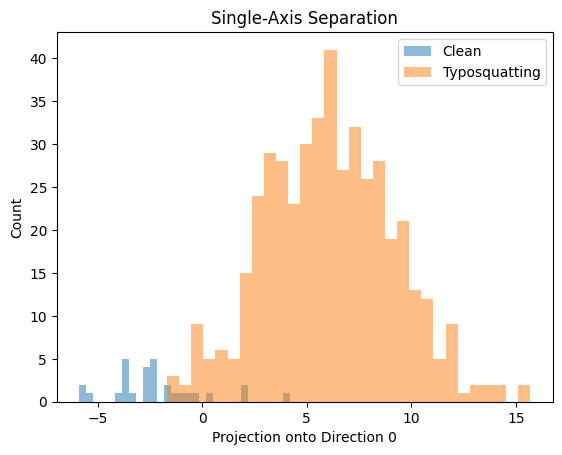

In [ ]:
# Project test set onto direction 0 only
proj0 = X_sub @ W[0]   # (n,)

# Train a 1‑D logistic regression on that scalar
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
probe_1d = LogisticRegression().fit(proj0.reshape(-1,1), y_sub)
auc_1d = roc_auc_score(y_sub, probe_1d.predict_proba(proj0.reshape(-1,1))[:,1])
print(f"1‑D probe AUC (direction 0 only): {auc_1d:.4f}")

# Histogram of the projection
import matplotlib.pyplot as plt
plt.hist(proj0[y_sub==0], bins=30, alpha=0.5, label='Clean')
plt.hist(proj0[y_sub==1], bins=30, alpha=0.5, label='Typosquatting')
plt.xlabel('Projection onto Direction 0')
plt.ylabel('Count')
plt.legend()
plt.title('Single‑Axis Separation')
plt.show()

t=0.050, Shapley: [2.88609633e+01 7.88935548e+06 8.16582582e+05 2.30235527e+06
 1.93445380e+06 7.36614679e+05]
t=0.100, Shapley: [2755304.28322677 4609267.977878   2854194.3809879   799680.66599834
  571180.49242039  692633.93965093]
t=0.150, Shapley: [2430222.76495752 1687848.05940022 1517879.86872751 6035066.97029961
  404905.57324366  317970.30053523]
t=0.200, Shapley: [ 750451.13312331  992103.98049302 1335759.54318451  405447.03824265
  175868.36608791   73410.21421373]
t=0.250, Shapley: [ 125548.60510649 1922345.21815077  711374.73818808  973440.94370003
  772470.25271412  290227.68831465]
t=0.300, Shapley: [ 633510.72553508 2026148.00431149 7970601.99857623 3345183.28300263
 1823346.45442313 1029759.58408565]
t=0.350, Shapley: [1367773.52702472 3124284.62529393 5321327.52021299 3120054.81034569
 1335553.1072329  1201783.62375627]
t=0.400, Shapley: [1356627.24047987 3411340.12213865 5741854.8208421  2714184.36486518
  628479.1193258   310129.93405344]
t=0.450, Shapley: [ 559621.6

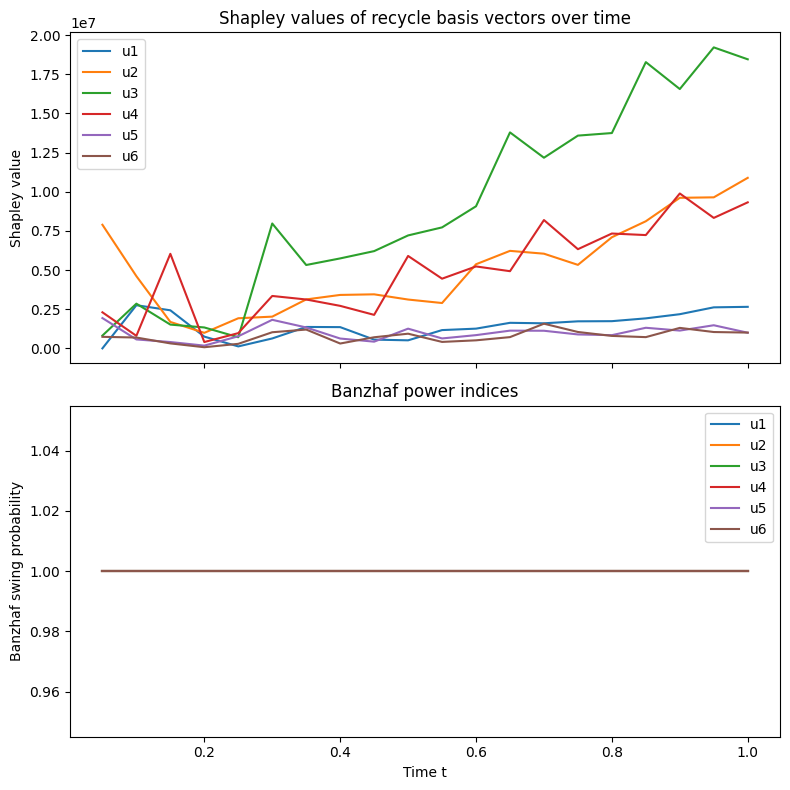

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, eye, diags
from scipy.sparse.linalg import spsolve, cg
from itertools import combinations
from math import comb

# ---------- PDE Discretisation ----------
def assemble_system(n, t):
    """Assemble A(t) and g(t) for n x n grid, time t."""
    h = 1.0 / (n + 1)
    # Coordinate arrays
    x = np.linspace(h, 1 - h, n)
    y = np.linspace(h, 1 - h, n)
    X, Y = np.meshgrid(x, y)

    # Coefficient a(x,y,t)
    a = np.exp(-(X - 0.5)**2 - (Y - 0.5)**2) * np.cos(t * X) + 2.1
    a_flat = a.ravel()

    # 5-point stencil for -∇·(a ∇f)
    # Use second-order centred differences for simplicity (fast to build)
    N = n * n
    main_diag = np.zeros(N)
    offx_diag = np.zeros(N - 1)
    offy_diag = np.zeros(N - n)

    # Interior points
    for j in range(n):
        for i in range(n):
            k = j * n + i
            # a at half-grid points for fluxes
            a_west = 0.5 * (a_flat[k] + a_flat[k - 1]) if i > 0 else a_flat[k]
            a_east = 0.5 * (a_flat[k] + a_flat[k + 1]) if i < n - 1 else a_flat[k]
            a_south = 0.5 * (a_flat[k] + a_flat[k - n]) if j > 0 else a_flat[k]
            a_north = 0.5 * (a_flat[k] + a_flat[k + n]) if j < n - 1 else a_flat[k]

            # Contributions
            main_diag[k] = (a_west + a_east + a_south + a_north) / h**2
            if i > 0:
                offx_diag[k - 1] = -a_west / h**2
            if i < n - 1:
                offx_diag[k] = -a_east / h**2
            if j > 0:
                offy_diag[k - n] = -a_south / h**2
            if j < n - 1:
                offy_diag[k] = -a_north / h**2

    A = diags([main_diag, offx_diag, offx_diag, offy_diag, offy_diag],
              [0, -1, 1, -n, n], shape=(N, N), format='csr')

    # Exact solution and source
    f_exact = np.sin(4 * np.pi * Y * t) * np.sin(15 * np.pi * X * t) * \
              (1 + np.sin(15 * np.pi * X * t) * np.cos(3 * np.pi * Y * t) *
               np.exp((X - 0.5)**2 + (Y - 0.5)**2 - 0.25**2))
    f_flat = f_exact.ravel()

    # g = A f (exact)
    g = A @ f_flat
    return A, g, f_flat

# ---------- Subspace Recycling ----------
def initial_guess(A, g, U):
    """Return z* solving min ||g - A U z||_2."""
    if U.shape[1] == 0:
        return np.zeros(U.shape[0]), np.linalg.norm(g)
    AU = A @ U
    z, residuals, rank, s = np.linalg.lstsq(AU, g, rcond=None)
    f0 = U @ z
    residual_norm = np.linalg.norm(g - A @ f0)
    return f0, residual_norm

# ---------- Game Theoretic Analysis ----------
def game_value(S, A, g, U):
    """Return v(S): reduction in residual norm using columns S of U."""
    if len(S) == 0:
        return 0.0
    Us = U[:, list(S)]
    _, res_norm = initial_guess(A, g, Us)
    base_res = np.linalg.norm(g)  # norm with zero initial guess
    return base_res - res_norm

def shapley_banzhaf(A, g, U):
    """Compute Shapley values and Banzhaf power indices for basis U."""
    m = U.shape[1]
    shap = np.zeros(m)
    banz = np.zeros(m)
    # Precompute all coalition values
    vals = {}
    for r in range(1 << m):
        S = [i for i in range(m) if (r >> i) & 1]
        vals[frozenset(S)] = game_value(S, A, g, U)
    # Shapley
    for i in range(m):
        tot = 0.0
        for r in range(1 << m):
            if (r >> i) & 1: continue
            S = [j for j in range(m) if (r >> j) & 1]
            k = len(S)
            weight = 1.0 / (comb(m - 1, k) * m)  # using combinatorial form
            tot += (vals[frozenset(S + [i])] - vals[frozenset(S)]) * comb(m - 1, k)
        shap[i] = tot
    # Banzhaf: all coalitions not containing i
    total_flips = np.zeros(m)
    for i in range(m):
        for r in range(1 << m):
            if (r >> i) & 1: continue
            S = [j for j in range(m) if (r >> j) & 1]
            # Count swing: does adding i change the value?
            if abs(vals[frozenset(S + [i])] - vals[frozenset(S)]) > 1e-10:
                total_flips[i] += 1
    total_coalitions = 2 ** (m - 1)  # number of coalitions not containing i
    banz = total_flips / total_coalitions if total_coalitions > 0 else 0.0
    return shap, banz

# ---------- Main Simulation ----------
n = 50                     # grid size (50x50 -> 2500 unknowns)
m = 6                      # history size
dt = 0.01                  # time step
T = 1.0                    # total time
num_steps = int(T / dt)
save_every = 5             # analyse every 5 steps

# Initialise
t = 0.0
A, g, f0 = assemble_system(n, t)
# Solve first system
f = spsolve(A, g)
history = [f]
U = f.reshape(-1, 1)       # orthonormal basis of history

# Store metrics
time_points = []
shap_series = []
banz_series = []

for step in range(1, num_steps + 1):
    t = step * dt
    A, g, _ = assemble_system(n, t)

    # 1. Initial guess from subspace
    f_guess, _ = initial_guess(A, g, U)

    # 2. Solve (direct, since A is SPD and not too large)
    f = spsolve(A, g)

    # 3. Update history and orthonormalise
    history.append(f)
    if len(history) > m:
        history.pop(0)
    # Orthonormalise the n x len(history) matrix via QR
    H = np.column_stack(history)
    U, _ = np.linalg.qr(H)   # U has orthonormal columns

    # 4. Game-theoretic audit
    if step % save_every == 0:
        shap, banz = shapley_banzhaf(A, g, U)
        time_points.append(t)
        shap_series.append(shap)
        banz_series.append(banz)
        print(f"t={t:.3f}, Shapley: {shap}")

# Convert to arrays
shap_arr = np.array(shap_series)
banz_arr = np.array(banz_series)

# ---------- Plotting ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for j in range(m):
    ax1.plot(time_points, shap_arr[:, j], label=f'u{j+1}')
ax1.set_ylabel('Shapley value')
ax1.legend()
ax1.set_title('Shapley values of recycle basis vectors over time')

for j in range(m):
    ax2.plot(time_points, banz_arr[:, j], label=f'u{j+1}')
ax2.set_ylabel('Banzhaf swing probability')
ax2.set_xlabel('Time t')
ax2.legend()
ax2.set_title('Banzhaf power indices')

plt.tight_layout()
plt.show()

t=0.050, Shapley (norm): [0.    0.574 0.065 0.09  0.21  0.059], Banzhaf (norm): [0.844 1.    1.    1.    1.    1.   ], EffDim=6
t=0.100, Shapley (norm): [0.222 0.386 0.205 0.068 0.055 0.064], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.150, Shapley (norm): [0.158 0.083 0.176 0.52  0.033 0.03 ], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.200, Shapley (norm): [0.19  0.265 0.384 0.093 0.045 0.022], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.250, Shapley (norm): [0.017 0.413 0.117 0.195 0.191 0.068], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.300, Shapley (norm): [0.044 0.103 0.484 0.189 0.125 0.056], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.350, Shapley (norm): [0.081 0.207 0.355 0.191 0.08  0.086], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.400, Shapley (norm): [0.09  0.233 0.431 0.18  0.042 0.024], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], EffDim=6
t=0.450, Shapley (norm): [0.029 0.248 0.503 0.128 0.031 0.061], Banzhaf (norm): [1. 1. 1. 1. 1. 1.], E

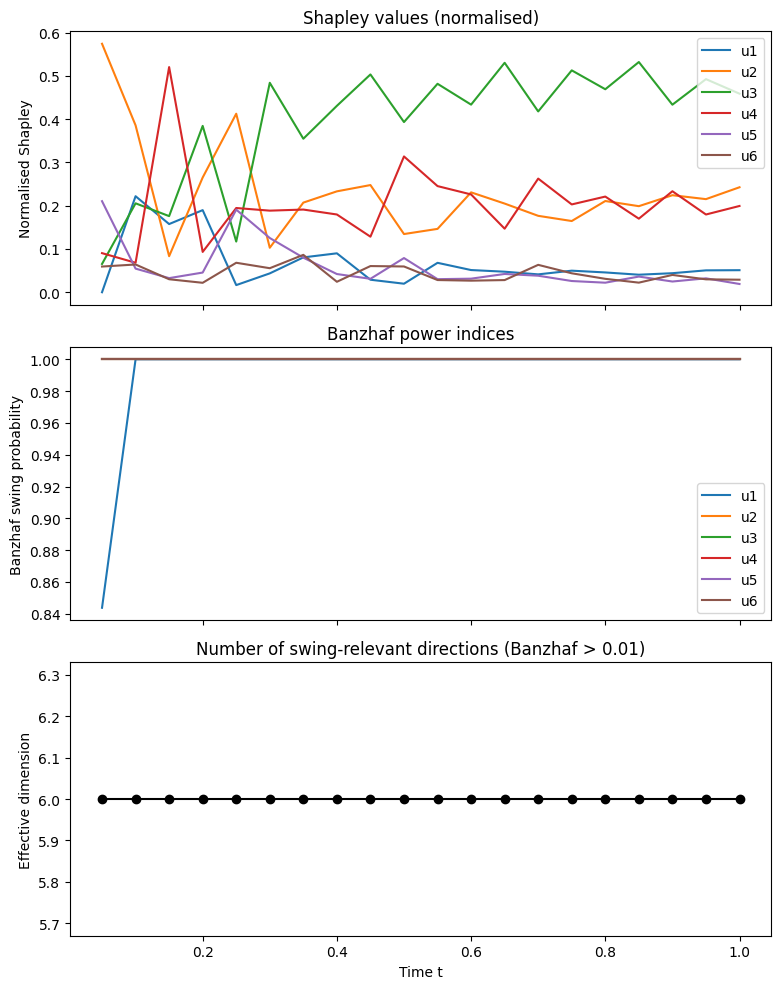

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, eye, diags
from scipy.sparse.linalg import spsolve, cg
from itertools import combinations
from math import comb

# ---------- PDE Discretisation ----------
def assemble_system(n, t):
    """Assemble A(t) and g(t) for n x n grid, time t."""
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1 - h, n)
    y = np.linspace(h, 1 - h, n)
    X, Y = np.meshgrid(x, y)

    a = np.exp(-(X - 0.5)**2 - (Y - 0.5)**2) * np.cos(t * X) + 2.1
    a_flat = a.ravel()

    N = n * n
    main_diag = np.zeros(N)
    offx_diag = np.zeros(N - 1)
    offy_diag = np.zeros(N - n)

    for j in range(n):
        for i in range(n):
            k = j * n + i
            a_west = 0.5 * (a_flat[k] + a_flat[k - 1]) if i > 0 else a_flat[k]
            a_east = 0.5 * (a_flat[k] + a_flat[k + 1]) if i < n - 1 else a_flat[k]
            a_south = 0.5 * (a_flat[k] + a_flat[k - n]) if j > 0 else a_flat[k]
            a_north = 0.5 * (a_flat[k] + a_flat[k + n]) if j < n - 1 else a_flat[k]

            main_diag[k] = (a_west + a_east + a_south + a_north) / h**2
            if i > 0:
                offx_diag[k - 1] = -a_west / h**2
            if i < n - 1:
                offx_diag[k] = -a_east / h**2
            if j > 0:
                offy_diag[k - n] = -a_south / h**2
            if j < n - 1:
                offy_diag[k] = -a_north / h**2

    A = diags([main_diag, offx_diag, offx_diag, offy_diag, offy_diag],
              [0, -1, 1, -n, n], shape=(N, N), format='csr')

    f_exact = np.sin(4 * np.pi * Y * t) * np.sin(15 * np.pi * X * t) * \
              (1 + np.sin(15 * np.pi * X * t) * np.cos(3 * np.pi * Y * t) *
               np.exp((X - 0.5)**2 + (Y - 0.5)**2 - 0.25**2))
    f_flat = f_exact.ravel()

    g = A @ f_flat
    return A, g, f_flat

# ---------- Subspace Recycling ----------
def initial_guess(A, g, U):
    """Return z* solving min ||g - A U z||_2."""
    if U.shape[1] == 0:
        return np.zeros(U.shape[0]), np.linalg.norm(g)
    AU = A @ U
    z, residuals, rank, s = np.linalg.lstsq(AU, g, rcond=None)
    f0 = U @ z
    residual_norm = np.linalg.norm(g - A @ f0)
    return f0, residual_norm

# ---------- Game Theoretic Analysis (Improved) ----------
def game_value_sq(S, A, g, U):
    """Return v(S): squared norm of projection onto A*span(U_S)."""
    if len(S) == 0:
        return 0.0
    Us = U[:, list(S)]
    AU = A @ Us
    z, residuals, rank, s = np.linalg.lstsq(AU, g, rcond=None)
    residual = np.linalg.norm(g - AU @ z)
    return np.linalg.norm(g)**2 - residual**2   # reduction in squared‑norm

def shapley_banzhaf(A, g, U):
    """Compute Shapley values and Banzhaf power indices for basis U."""
    m = U.shape[1]
    shap = np.zeros(m)
    banz = np.zeros(m)
    vals = {}
    for r in range(1 << m):
        S = [i for i in range(m) if (r >> i) & 1]
        vals[frozenset(S)] = game_value_sq(S, A, g, U)

    grand_val = vals[frozenset(range(m))]
    eps = 1e-8 * grand_val  # relative threshold for Banzhaf

    # Shapley using combinatorial formula
    for i in range(m):
        tot = 0.0
        for r in range(1 << m):
            if (r >> i) & 1: continue
            S = [j for j in range(m) if (r >> j) & 1]
            k = len(S)
            weight = 1.0 / (comb(m - 1, k) * m)
            tot += (vals[frozenset(S + [i])] - vals[frozenset(S)]) * comb(m - 1, k)
        shap[i] = tot

    # Banzhaf
    total_coalitions = 2 ** (m - 1)
    for i in range(m):
        flips = 0
        for r in range(1 << m):
            if (r >> i) & 1: continue
            S = [j for j in range(m) if (r >> j) & 1]
            if abs(vals[frozenset(S + [i])] - vals[frozenset(S)]) > eps:
                flips += 1
        banz[i] = flips / total_coalitions if total_coalitions > 0 else 0.0

    # Normalise Shapley to sum to 1
    if shap.sum() > 0:
        shap /= shap.sum()
    return shap, banz

# ---------- Main Simulation ----------
n = 50
m = 6
dt = 0.01
T = 1.0
num_steps = int(T / dt)
save_every = 5

t = 0.0
A, g, f0 = assemble_system(n, t)
f = spsolve(A, g)
history = [f]
U = f.reshape(-1, 1)

time_points = []
shap_series = []
banz_series = []
eff_dim_series = []

for step in range(1, num_steps + 1):
    t = step * dt
    A, g, _ = assemble_system(n, t)

    f_guess, _ = initial_guess(A, g, U)
    f = spsolve(A, g)

    history.append(f)
    if len(history) > m:
        history.pop(0)
    H = np.column_stack(history)
    U, _ = np.linalg.qr(H)

    if step % save_every == 0:
        shap, banz = shapley_banzhaf(A, g, U)
        time_points.append(t)
        shap_series.append(shap)
        banz_series.append(banz)
        eff_dim = sum(banz > 0.01)
        eff_dim_series.append(eff_dim)
        print(f"t={t:.3f}, Shapley (norm): {np.round(shap,3)}, Banzhaf (norm): {np.round(banz,3)}, EffDim={eff_dim}")

shap_arr = np.array(shap_series)
banz_arr = np.array(banz_series)
eff_dim_arr = np.array(eff_dim_series)

# ---------- Plotting ----------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for j in range(m):
    ax1.plot(time_points, shap_arr[:, j], label=f'u{j+1}')
ax1.set_ylabel('Normalised Shapley')
ax1.legend()
ax1.set_title('Shapley values (normalised)')

for j in range(m):
    ax2.plot(time_points, banz_arr[:, j], label=f'u{j+1}')
ax2.set_ylabel('Banzhaf swing probability')
ax2.legend()
ax2.set_title('Banzhaf power indices')

ax3.plot(time_points, eff_dim_arr, 'ko-')
ax3.set_ylabel('Effective dimension')
ax3.set_xlabel('Time t')
ax3.set_title('Number of swing‑relevant directions (Banzhaf > 0.01)')

plt.tight_layout()
plt.show()

Loading dataset...
Train: 2249, Test: 483


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base model loaded.
Extracting hidden states (this may take a few minutes)...
X_train: (2249, 1536), X_test: (483, 1536)

Training probe with 10 samples
Probe AUC: 0.8094
Building 30 orthogonal directions...


Orthogonalization: 100%|██████████| 30/30 [00:01<00:00, 16.36it/s]


Computing Shapley (800 permutations)...
Computing Banzhaf (500 coalitions)...
Dominant Shapley: 0.8115, Coalition size: 4, Eff. Banzhaf dim: 17

Training probe with 50 samples
Probe AUC: 0.8988
Building 30 orthogonal directions...


...

Computing Shapley (800 permutations)...
Computing Banzhaf (500 coalitions)...
Dominant Shapley: 0.9903, Coalition size: 1, Eff. Banzhaf dim: 30

Training probe with 500 samples
Probe AUC: 0.9720
Building 30 orthogonal directions...


Orthogonalization:   3%|▎         | 1/30 [00:01<00:54,  1.87s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Orthogonalization:   7%|▋         | 2/30 [00:06<01:44,  3.73s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation

Computing Shapley (800 permutations)...
Computing Banzhaf (500 coalitions)...
Dominant Shapley: 0.9959, Coalition size: 1, Eff. Banzhaf dim: 30

Training probe with all samples
Probe AUC: 0.9820
Building 30 orthogonal directions...


Orthogonalization:   3%|▎         | 1/30 [00:06<02:59,  6.18s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Orthogonalization:   7%|▋         | 2/30 [00:15<03:39,  7.85s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation

Computing Shapley (800 permutations)...
Computing Banzhaf (500 coalitions)...
Dominant Shapley: 0.9294, Coalition size: 4, Eff. Banzhaf dim: 30


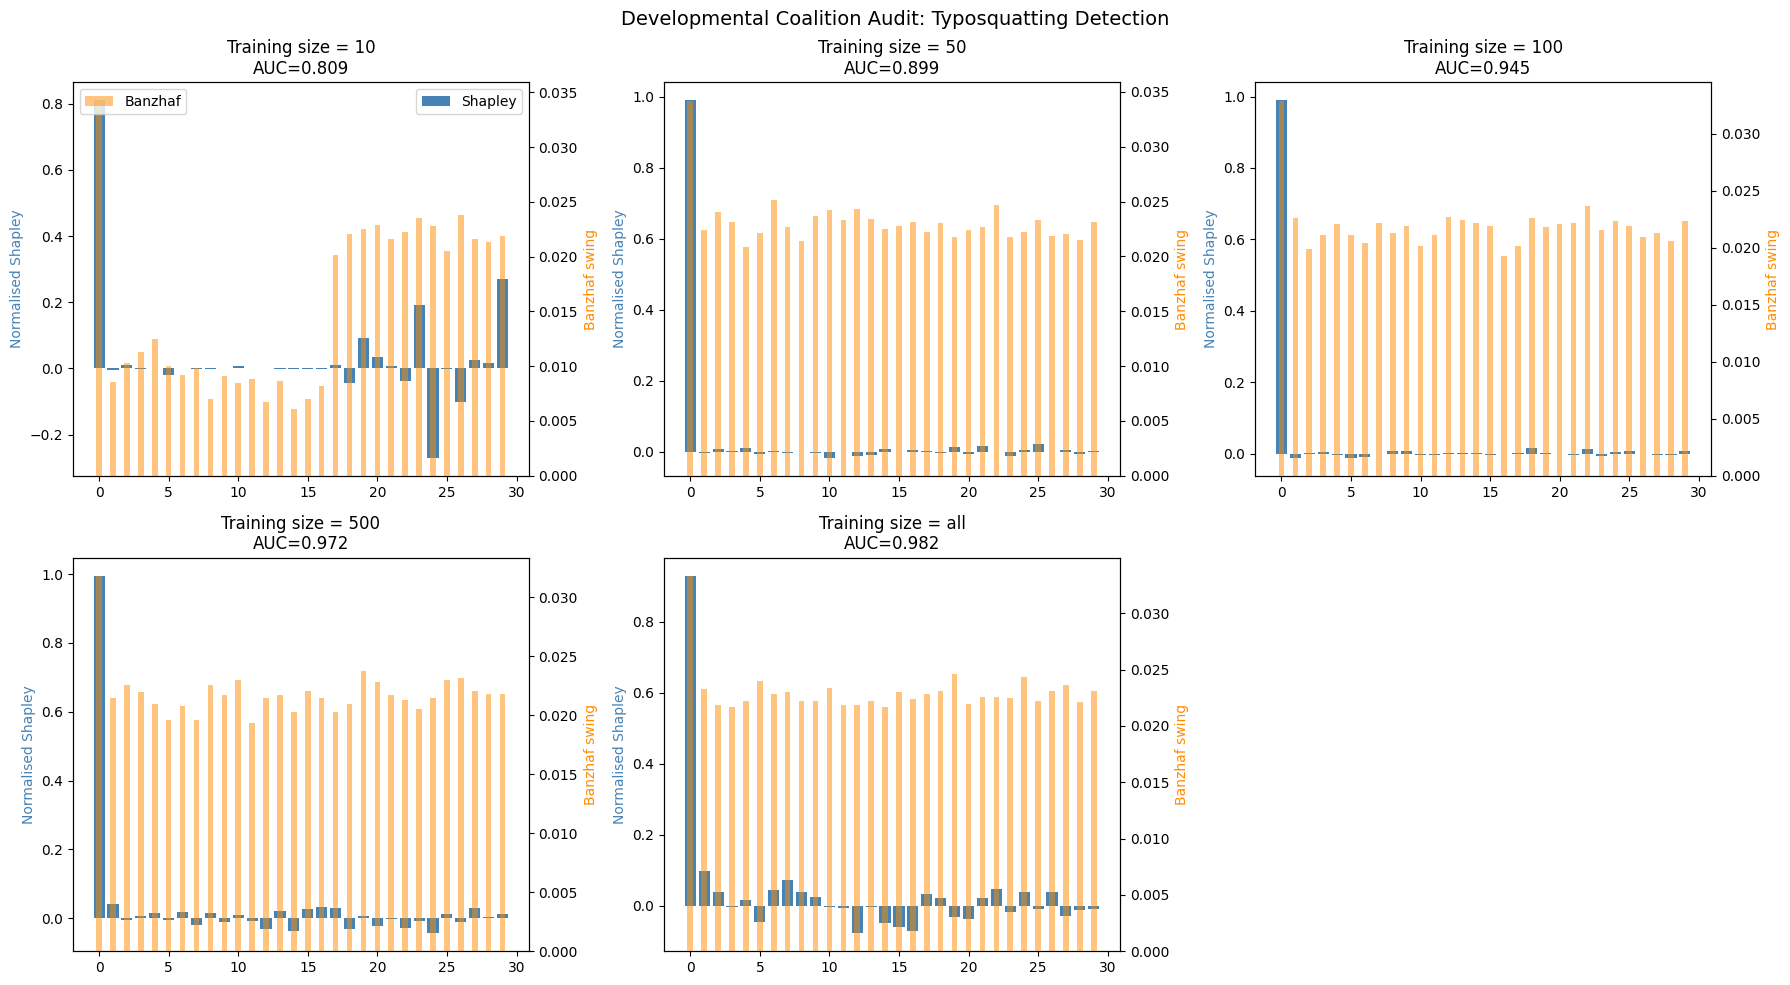

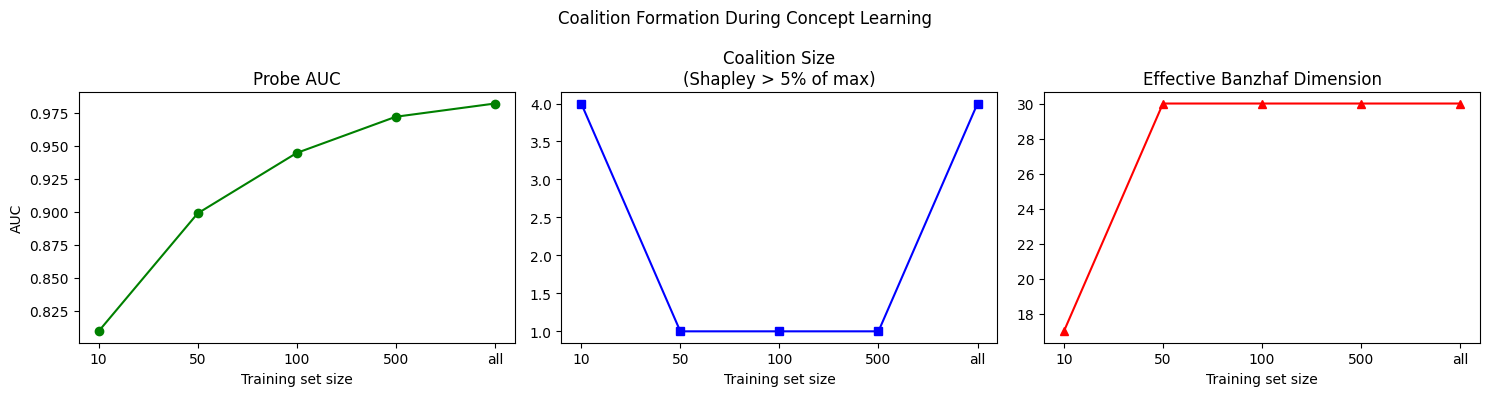


✅ Done.


In [ ]:
# ------------------------------------------------------------
# Developmental Coalition Audit – Using Increasing Training Data
# ------------------------------------------------------------
import json, os, zipfile
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, AutoModelForCausalLM

# ----------------------------- CONFIG -----------------------------
PROBE_LAYER = 26
BATCH_SIZE = 16
N_DIRECTIONS = 30
N_PERMUTATIONS = 800
N_BANZHAF_COALITIONS = 500
SUBSAMPLE_TEST = 2000
BASELINE_AUC = 0.5
BANZHAF_REL_THRESH = 1e-6

training_sizes = [10, 50, 100, 500, "all"]  # "all" means all 2249 training samples

# --------------------- 1. LOAD DATASET ---------------------
if not os.path.exists('dataset/typosquat_dataset_full/typosquat_tool_calls.jsonl'):
    with zipfile.ZipFile('typosquat_dataset_full.zip', 'r') as zf:
        zf.extractall('dataset/')

DATA_PATH = 'dataset/typosquat_dataset_full/typosquat_tool_calls.jsonl'
print("Loading dataset...")
texts, labels, splits = [], [], []
with open(DATA_PATH, 'r') as f:
    for line in f:
        obj = json.loads(line)
        if obj['is_adversarial']:
            texts.append(obj['typo_command'])
            labels.append(1)
        else:
            texts.append(obj['clean_command'])
            labels.append(0)
        splits.append(obj['split'])

texts = np.array(texts)
labels = np.array(labels)
splits = np.array(splits)

train_texts = texts[splits == 'train']
train_labels = labels[splits == 'train']
test_texts = texts[splits == 'test']
test_labels = labels[splits == 'test']

print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

# --------------------- 2. LOAD BASE MODEL ONCE ---------------------
model_name = "Qwen/Qwen2.5-1.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
print("Base model loaded.")

def get_hidden_states(text_list):
    """Return mean‑pooled hidden states from PROBE_LAYER."""
    all_hidden = []
    for i in range(0, len(text_list), BATCH_SIZE):
        batch = text_list[i:i+BATCH_SIZE].tolist() if hasattr(text_list, 'tolist') else text_list[i:i+BATCH_SIZE]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden = outputs.hidden_states[PROBE_LAYER].mean(dim=1).cpu().float().numpy()
        all_hidden.append(hidden)
    return np.concatenate(all_hidden, axis=0)

# Extract all hidden states ONCE
print("Extracting hidden states (this may take a few minutes)...")
X_train_full = get_hidden_states(train_texts)
X_test_full  = get_hidden_states(test_texts)
y_train_full = train_labels
y_test_full = test_labels
print(f"X_train: {X_train_full.shape}, X_test: {X_test_full.shape}")

# Subsample test set for speed
if SUBSAMPLE_TEST is not None and len(X_test_full) > SUBSAMPLE_TEST:
    idx = np.random.choice(len(X_test_full), SUBSAMPLE_TEST, replace=False)
    X_test_sub = X_test_full[idx]
    y_test_sub = y_test_full[idx]
else:
    X_test_sub = X_test_full
    y_test_sub = y_test_full

# --------------------- 3. GAME‑THEORETIC UTILITIES ---------------------
def coalition_value_auc(subset_indices, W, X, y, probe):
    if not subset_indices:
        return BASELINE_AUC
    selected_W = W[list(subset_indices)]
    coeffs = X @ selected_W.T
    X_proj = coeffs @ selected_W
    return roc_auc_score(y, probe.predict_proba(X_proj)[:, 1])

def permutation_shapley(W, X, y, probe, n_perm):
    m = W.shape[0]
    marg_contrib = {i: [] for i in range(m)}
    for _ in range(n_perm):
        perm = np.random.permutation(m)
        S = set()
        prev_val = coalition_value_auc(S, W, X, y, probe)
        for i in perm:
            S.add(i)
            curr_val = coalition_value_auc(S, W, X, y, probe)
            marg_contrib[i].append(curr_val - prev_val)
            prev_val = curr_val
    shap = np.array([np.mean(marg_contrib[i]) for i in range(m)])
    total = shap.sum()
    return shap / total if total > 0 else shap

def monte_carlo_banzhaf(W, X, y, probe, n_coal, rel_thresh):
    m = W.shape[0]
    grand_val = coalition_value_auc(set(range(m)), W, X, y, probe)
    eps = rel_thresh * grand_val
    flips = np.zeros(m)
    total = 0
    for _ in range(n_coal):
        k = np.random.randint(0, m)
        coalition = set(np.random.choice(m, size=k, replace=False))
        val_without = coalition_value_auc(coalition, W, X, y, probe)
        for i in range(m):
            if i not in coalition:
                val_with = coalition_value_auc(coalition | {i}, W, X, y, probe)
                if abs(val_with - val_without) > eps:
                    flips[i] += 1
                total += 1
    return flips / total if total > 0 else np.zeros(m)

# --------------------- 4. LOOP OVER TRAINING SIZES ---------------------
results = []

for size in training_sizes:
    label = str(size)
    print(f"\n{'='*40}\nTraining probe with {size} samples\n{'='*40}")

    # Select subset of training data (stratified)
    if size == "all":
        X_train = X_train_full
        y_train = y_train_full
    else:
        from sklearn.model_selection import train_test_split
        X_train, _, y_train, _ = train_test_split(
            X_train_full, y_train_full, train_size=size, stratify=y_train_full, random_state=42
        )

    # Train probe
    probe = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    auc = roc_auc_score(y_test_sub, probe.predict_proba(X_test_sub)[:, 1])
    print(f"Probe AUC: {auc:.4f}")

    # Build orthogonal directions
    print(f"Building {N_DIRECTIONS} orthogonal directions...")
    d = X_train.shape[1]
    remaining = X_train.copy()
    ortho = []
    for i in tqdm(range(N_DIRECTIONS), desc='Orthogonalization'):
        p = LogisticRegression(max_iter=1000).fit(remaining, y_train)
        w = p.coef_[0]
        w = w / np.linalg.norm(w)
        for prev in ortho:
            w -= np.dot(w, prev) * prev
        w = w / np.linalg.norm(w)
        ortho.append(w)
        proj = remaining @ w
        remaining -= np.outer(proj, w)
    W = np.stack(ortho)

    # Shapley
    print(f"Computing Shapley ({N_PERMUTATIONS} permutations)...")
    shap = permutation_shapley(W, X_test_sub, y_test_sub, probe, N_PERMUTATIONS)

    # Banzhaf
    print(f"Computing Banzhaf ({N_BANZHAF_COALITIONS} coalitions)...")
    banz = monte_carlo_banzhaf(W, X_test_sub, y_test_sub, probe, N_BANZHAF_COALITIONS, BANZHAF_REL_THRESH)

    # Metrics
    max_shap = shap.max() if shap.max() > 0 else 1e-10
    coalition_size = np.sum(shap > 0.05 * max_shap)
    eff_dim = np.sum(banz > 0.01)

    results.append({
        'label': label,
        'shap': shap,
        'banz': banz,
        'auc': auc,
        'coalition_size': coalition_size,
        'eff_dim': eff_dim,
    })
    print(f"Dominant Shapley: {max_shap:.4f}, Coalition size: {coalition_size}, Eff. Banzhaf dim: {eff_dim}")

# --------------------- 5. PLOT ---------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, res in enumerate(results):
    if idx >= 6:
        break   # we only have 5 results, the 6th subplot stays empty
    ax = axes[idx]
    ax.bar(range(N_DIRECTIONS), res['shap'], color='steelblue', label='Shapley')
    ax2 = ax.twinx()
    ax2.bar(range(N_DIRECTIONS), res['banz'], color='darkorange', alpha=0.5, width=0.4, label='Banzhaf')
    ax.set_title(f"Training size = {res['label']}\nAUC={res['auc']:.3f}")
    ax.set_ylabel("Normalised Shapley", color='steelblue')
    ax2.set_ylabel("Banzhaf swing", color='darkorange')
    if idx == 0:
        ax.legend(loc='upper right')
        ax2.legend(loc='upper left')

# Remove empty subplot if necessary
if len(results) < len(axes):
    for idx in range(len(results), len(axes)):
        axes[idx].set_visible(False)

fig.suptitle("Developmental Coalition Audit: Typosquatting Detection", fontsize=14)
plt.tight_layout()
plt.show()

# Summary plot
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
labels = [r['label'] for r in results]
ax1.plot(labels, [r['auc'] for r in results], 'o-', color='green')
ax1.set_title("Probe AUC")
ax1.set_ylabel("AUC")
ax2.plot(labels, [r['coalition_size'] for r in results], 's-', color='blue')
ax2.set_title("Coalition Size\n(Shapley > 5% of max)")
ax3.plot(labels, [r['eff_dim'] for r in results], '^-', color='red')
ax3.set_title("Effective Banzhaf Dimension")
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("Training set size")
plt.suptitle("Coalition Formation During Concept Learning")
plt.tight_layout()
plt.show()

print("\n✅ Done.")